# Tests of running synthpop

## Imports

In [6]:
# from dustmaps.config import config

# config['data_dir'] = "/home/emily/data/dustmaps"

In [ ]:
from __future__ import annotations
import synthpop
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gaianir_open_clusters.config import (
    SYNTHPOP_CONFIG_DIRECTORY,
    SYNTHPOP_DEFAULT_CONFIG,
    SYNTHPOP_GAIANIR_CONFIG,
    DATA_DIRECTORY
)
from gaianir_open_clusters.util import HiddenPrints
from gaianir_open_clusters.photometry import PHOTOMETRY_PREDICTOR, EXTINCTION_MODELS
from gaianir_open_clusters.astrometry import (
    AstrometryModelElectronBased,
    AstrometryModel,
    combine_astrometry,
)

from astropy.coordinates import SkyCoord, CartesianRepresentation, CartesianDifferential
from astropy import units as u

from dustmaps.bayestar import BayestarQuery
from dustmaps.decaps import DECaPSQueryLite

from sklearn.neighbors import NearestNeighbors

import os
os.environ['OCELOT_DATA'] = (DATA_DIRECTORY / "ocelot_data").as_posix()

import ocelot.simulate.cluster
from ocelot.model.observation.gaia.photutils import AG

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/pydantic/_internal/_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [2]:
# Switches off the synthpop logging

from synthpop.synthpop_utils.synthpop_logging import logger
import logging

def dummy_func(*args, **kwargs):
    pass

logger.setLevel(logging.ERROR)
logger.stream_logger.setLevel(logging.ERROR)
# logger.filelogger.setLevel(logging.ERROR)
logger.debugger.setLevel(logging.ERROR)
logger.create_info_section = dummy_func
logger.create_info_subsection = dummy_func

In [4]:
# from dustmaps.bayestar import fetch as fetch_bayestar
# from dustmaps.decaps import fetch as fetch_decaps

# fetch_bayestar()
# fetch_decaps(mean_only=True)

bayestar_map = BayestarQuery(max_samples=1)
zucker_map = DECaPSQueryLite(mean_only=True)

Tip: To suppress this warning and skip confirmation in future runs, use silence_warnings=True.
Proceeding with the download...


  0.0 B of 8.0 GiB |   0.0 s/B |                        |   0% | ETA:  --:--:--
 17.0 KiB of 8.0 GiB | 157.8 KiB/s |                    |   0% | ETA:  14:46:01
 68.0 KiB of 8.0 GiB | 313.9 KiB/s |                    |   0% | ETA:   7:25:26
170.0 KiB of 8.0 GiB | 522.4 KiB/s |                    |   0% | ETA:   4:27:38
391.0 KiB of 8.0 GiB | 900.1 KiB/s |                    |   0% | ETA:   2:35:20
799.0 KiB of 8.0 GiB |   1.4 MiB/s |                    |   0% | ETA:   1:35:10
  1.6 MiB of 8.0 GiB |   2.5 MiB/s |                    |   0% | ETA:   0:55:21
  3.3 MiB of 8.0 GiB |   4.3 MiB/s |                    |   0% | ETA:   0:31:59
  6.5 MiB of 8.0 GiB |   7.5 MiB/s |                    |   0% | ETA:   0:18:13
  9.6 MiB of 8.0 GiB |   9.1 MiB/s |                    |   0% | ETA:   0:15:04
 13.3 MiB of 8.0 GiB |  11.2 MiB/s |                    |   0% | ETA:   0:12:08
 13.7 MiB of 8.0 GiB |  10.5 MiB/s |                    |   0% | ETA:   0:13:01
 17.2 MiB of 8.0 GiB |  12.1 MiB/s |    

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 16.336 s
  pix_info:   0.230 s
   samples:   2.637 s
      best:   2.493 s
       nan:   0.011 s
      sort:  10.892 s
       idx:   0.074 s
Loading meta pixel info...
Meta pixel info loaded!


## With a basic config

In [ ]:
model = synthpop.SynthPop(
        specific_config=SYNTHPOP_GAIANIR_CONFIG,
        default_config=SYNTHPOP_DEFAULT_CONFIG,
        # extinction_map_kwargs=dict(name="no_extinction"),
    )
model.init_populations()

 3853178 - Location or solid_angle_sr are not  defined in the settings! Can not run main() or process_all()


/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/synthpop/data/isochrones/mist/MIST_v1.2_vvcrit0.4_basic.txz: 211MB [00:09, 23.1MB/s]                            
Isochrones downloaded: basic
/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/synthpop/data/isochrones/mist/MIST_v1.2_vvcrit0.4_UBVRIplus.txz: 152MB [00:06, 25.2MB/s] 
Isochrones downloaded: UBVRIplus


/home/emily/code/gaianir-open-clusters/prototypes/synthpop/../../.venv/lib/python3.13/site-packages/synthpop/modules/population_density/density_from_grid.py:35: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', comment='#')
/home/emily/code/gaianir-open-clusters/prototypes/synthpop/../../.venv/lib/python3.13/site-packages/synthpop/modules/kinematics/kinematics_from_grid.py:40: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', comment='#')


In [10]:
model.populations_are_initialized

True

In [7]:
result = model.process_location(
    l_deg=10, b_deg=0, solid_angle=1 / 60**2, save_data=False
)[0]

In [6]:
print(len(result))

55845


In [7]:
result.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_None', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks'],
      dtype='object')

(array([  333.,  2444., 13185., 10942., 13292., 10249.,  3841.,  1121.,
          336.,   102.]),
 array([ 0.71757358,  3.13359641,  5.54961924,  7.96564207, 10.3816649 ,
        12.79768773, 15.21371056, 17.62973339, 20.04575622, 22.46177905,
        24.87780188]),
 <BarContainer object of 10 artists>)

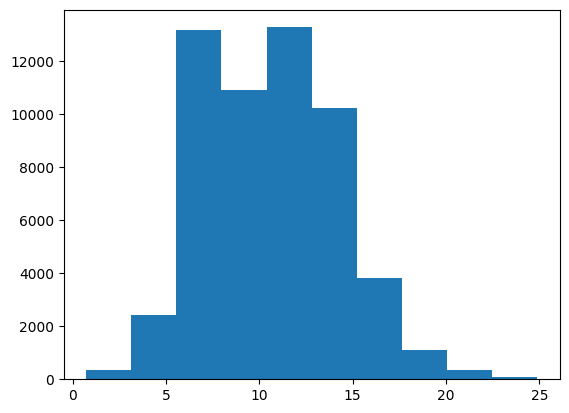

In [8]:
plt.hist(result['Dist'])

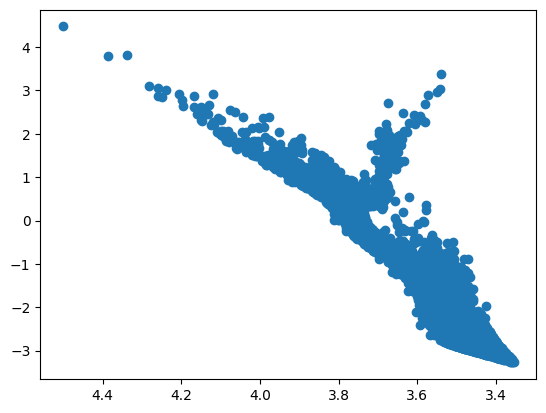

In [9]:
plt.scatter(result['logTeff'], result['logL'])
plt.gca().invert_xaxis()

In [10]:
result.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_None', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks'],
      dtype='object')

<Axes: >

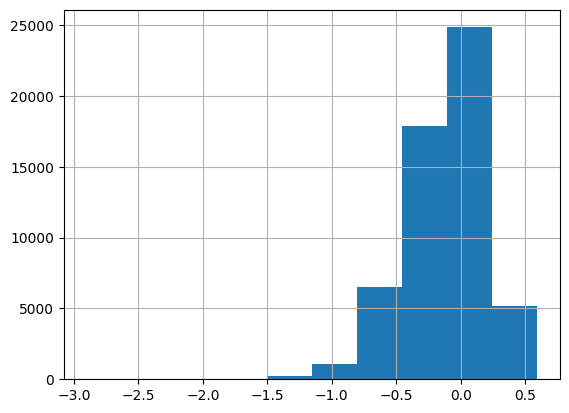

In [11]:
result['Fe/H_evolved'].hist()

:tada: it works!!

## Adding GaiaNIR information

In [82]:
result = model.process_location(
    l_deg=10, b_deg=0, solid_angle=1 / 60**2, save_data=False
)[0]

In [8]:
MAXIMUM_GAIA_MAG = 20
MAXIMUM_GAIANIR_MAG = 23


# Grab photometry
result["luminosity"] = 10 ** result["logL"]
result["temperature"] = 10 ** result["logTeff"]
result["log_g"] = result["logg"]
result = result.loc[result["temperature"].notna()].reset_index(drop=True)

result = PHOTOMETRY_PREDICTOR.predict(
    result, result["Fe/H_evolved"], luminosity_in_L_sun=True
)

dist = 5 * np.log10(result["Dist"] * 1000) - 5
for band in PHOTOMETRY_PREDICTOR.photometric_bands:
    result[band] = result[band] + dist

result["label"] = 0

# Convert to ICRS
coords = SkyCoord(
    CartesianRepresentation(
        result["x"].to_numpy(),
        result["y"].to_numpy(),
        result["z"].to_numpy(),
        unit=u.kpc,
        differentials=CartesianDifferential(
            result["U"].to_numpy(),
            result["V"].to_numpy(),
            result["W"].to_numpy(),
            unit=u.km / u.s,
        ),
    ),
    frame="galactocentric",
).transform_to("icrs")
result["ra"] = coords.ra.to(u.deg).value
result["dec"] = coords.dec.to(u.deg).value
result["pmra_true"] = coords.pm_ra_cosdec.to(u.mas / u.yr).value
result["pmdec_true"] = coords.pm_dec.to(u.mas / u.yr).value
result["parallax_true"] = 1 / result["Dist"]

# Grab extinction
result["extinction_green"] = bayestar_map.query(coords, mode="best")
result["extinction_zucker"] = zucker_map.query(coords, mode="mean")

result["extinction"] = np.where(
    result["extinction_zucker"].notna(),
    result["extinction_zucker"],
    result["extinction_green"],
)

# Apply extinctions
query_data = pd.DataFrame.from_dict(
    {
        "A0": np.clip(
            result["extinction"], 0, 50
        ),  # Clip as relation only valid to A_V=50
        "R0": 3.1,
        "teff": result["temperature"],
    }
)

for band in PHOTOMETRY_PREDICTOR.photometric_bands:
    result[band] = result[band] + result["extinction"] * np.asarray(
        EXTINCTION_MODELS[band].predict(query_data)
    )

result = result.loc[result['N'] < MAXIMUM_GAIANIR_MAG].reset_index(drop=True)

result["Gaia_G_EDR3"] = result["Gaia_G_EDR3"] + AG(
    result["extinction"], result["temperature"]
)

# Add GaiaNIR astrometry
model_gaianir = AstrometryModelElectronBased()
(
    result["pmra_error_gaianir"],
    result["pmdec_error_gaianir"],
    result["parallax_error"],
) = model_gaianir.predict(result["N"])

# Also add Gaia astrometry
model_dr5 = AstrometryModel(mission="Gaia")
good_stars = result["Gaia_G_EDR3"] < MAXIMUM_GAIA_MAG
result["temperature_boring"] = 5000  # Little/no impact
(
    result.loc[good_stars, "pmra_error_gaia"],
    result.loc[good_stars, "pmdec_error_gaia"],
    _,
) = model_dr5.predict(
    result.loc[good_stars],
    temperature_column="temperature_boring",
    mag_column="Gaia_G_EDR3",
)

result["pmra_error"] = result["pmra_error_gaianir"]
result["pmdec_error"] = result["pmdec_error_gaianir"]

# & combine it!
result.loc[good_stars, "pmra_error"], result.loc[good_stars, "pmdec_error"] = (
    combine_astrometry(
        result.loc[good_stars, "pmra_error_gaianir"],
        result.loc[good_stars, "pmdec_error_gaianir"],
        result.loc[good_stars, "pmra_error_gaia"],
        result.loc[good_stars, "pmdec_error_gaia"],
        20 + model_dr5.years / 2 + model_gaianir.years / 2,
    )
)

# FINALLY, sample it randomly
rng = np.random.default_rng()

result['pmra'] = rng.normal(loc=result['pmra_true'], scale=result['pmra_error'])
result['pmdec'] = rng.normal(loc=result['pmdec_true'], scale=result['pmdec_error'])
result['parallax'] = rng.normal(loc=result['parallax_true'], scale=result['parallax_error'])

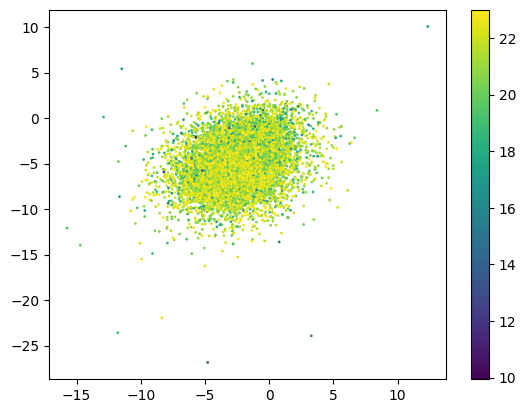

In [84]:
plt.scatter(result['pmra'], result['pmdec'], c=result['N'], s=1)
plt.colorbar()

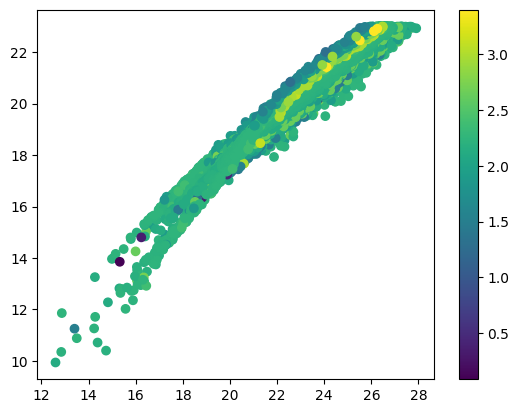

In [85]:
plt.scatter(result['Gaia_G_EDR3'], result['N'], c=result['extinction'])
plt.colorbar()

## Adding neighbor estimates

In [86]:
diffraction_limit = 1.22 * 1550 / (3.5e9)

neighbors = NearestNeighbors(radius=diffraction_limit, metric="haversine")
neighbors.fit(result[["ra", "dec"]] * np.pi / 180)
distances, indices = neighbors.radius_neighbors(result[["ra", "dec"]] * np.pi / 180)

(array([8.479e+03, 6.353e+03, 3.939e+03, 1.934e+03, 9.310e+02, 3.110e+02,
        8.600e+01, 3.100e+01, 3.000e+00, 1.000e+00]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

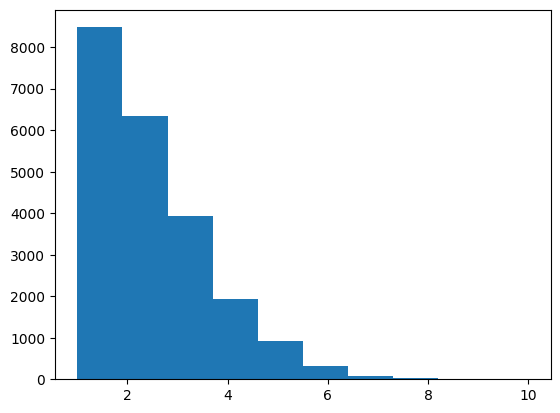

In [87]:
plt.hist([len(x) for x in indices])

oh damn! that's a lot of overlap...